# 🚀 Advanced / Large-Scale LLMs

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/03-advanced-llms/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/03-advanced-llms/index.qmd)

## 👋 Welcome

You already know how to make a model run on more than one GPU. In
[\[1.4\] Distributed
Training](../01-neural-networks/4-distributed-training/index.qmd) you
met the whole toolbox: `DDP`, collective ops (all-reduce, all-gather,
reduce-scatter), `ZeRO`, `FSDP`, tensor / pipeline / sequence
parallelism (TP / PP / SP), and how to combine them into **3D
parallelism**. In [\[2.1\] Parallel
Training](../02-llms/1-parallel-training/index.qmd) and the [\[2.2\]
Shakespeare](../02-llms/2-shakespeare-example-colab/index.ipynb) example
you put those ideas to work and pretrained a GPT from scratch.

**This track builds directly on that foundation.** “Large-scale” is not
just “the same training loop, but with more nodes.” Once a job spans
hundreds or thousands of GPUs and runs for days, a new set of problems
moves to center stage: how do you grow parameter count *without* growing
FLOPs per token (mixture-of-experts)? How do you keep a multi-day run
alive when a node inevitably dies (fault tolerance)? How do you feed the
pipeline fast enough that GPUs never starve (data + checkpoint
sharding)? And once the base model is trained, how do you *shape its
behavior* — instruction-following, alignment, and reasoning — with mid-
and post-training and reinforcement learning?

Each lab in this track follows the same **toy → real → scale** rhythm: a
tiny example that really runs on a laptop, an annotated look at a real
production config with actual log excerpts, and a guided
`ezpz launch [...]` step so you can reproduce it on the cluster.

## 🗺️ Map of this track

The five labs are meant to be read roughly in order, but each stands on
its own:

- **[\[3.0\] Mixture of Experts & Expert Parallelism](0-moe/index.qmd)**
  — sparse models that route each token to a few experts, and the
  *expert parallelism* needed to shard those experts across devices.
- **[\[3.1\] Pretraining at Scale](1-pretraining-at-scale/index.qmd)** —
  putting 3D parallelism, data sharding, and DCP checkpointing together
  for a real multi-node pretraining run with `torchtitan`.
- **[\[3.2\] Fault-Tolerant
  Training](2-fault-tolerant-training/index.qmd)** — surviving node
  failures with checkpointing, spare nodes, and auto-retry so a
  multi-day run actually finishes.
- **[\[3.3\] Mid- & Post-Training](3-mid-post-training/index.qmd)** —
  continued pretraining, supervised fine-tuning (SFT), and
  parameter-efficient methods (LoRA) that adapt a base model to a task.
- **[\[3.4\] RL & Reasoning Models](4-rl-and-reasoning/index.qmd)** —
  preference optimization (DPO) and RL (PPO / GRPO) that teach models to
  align and to *reason*.

## 🧭 Where this fits

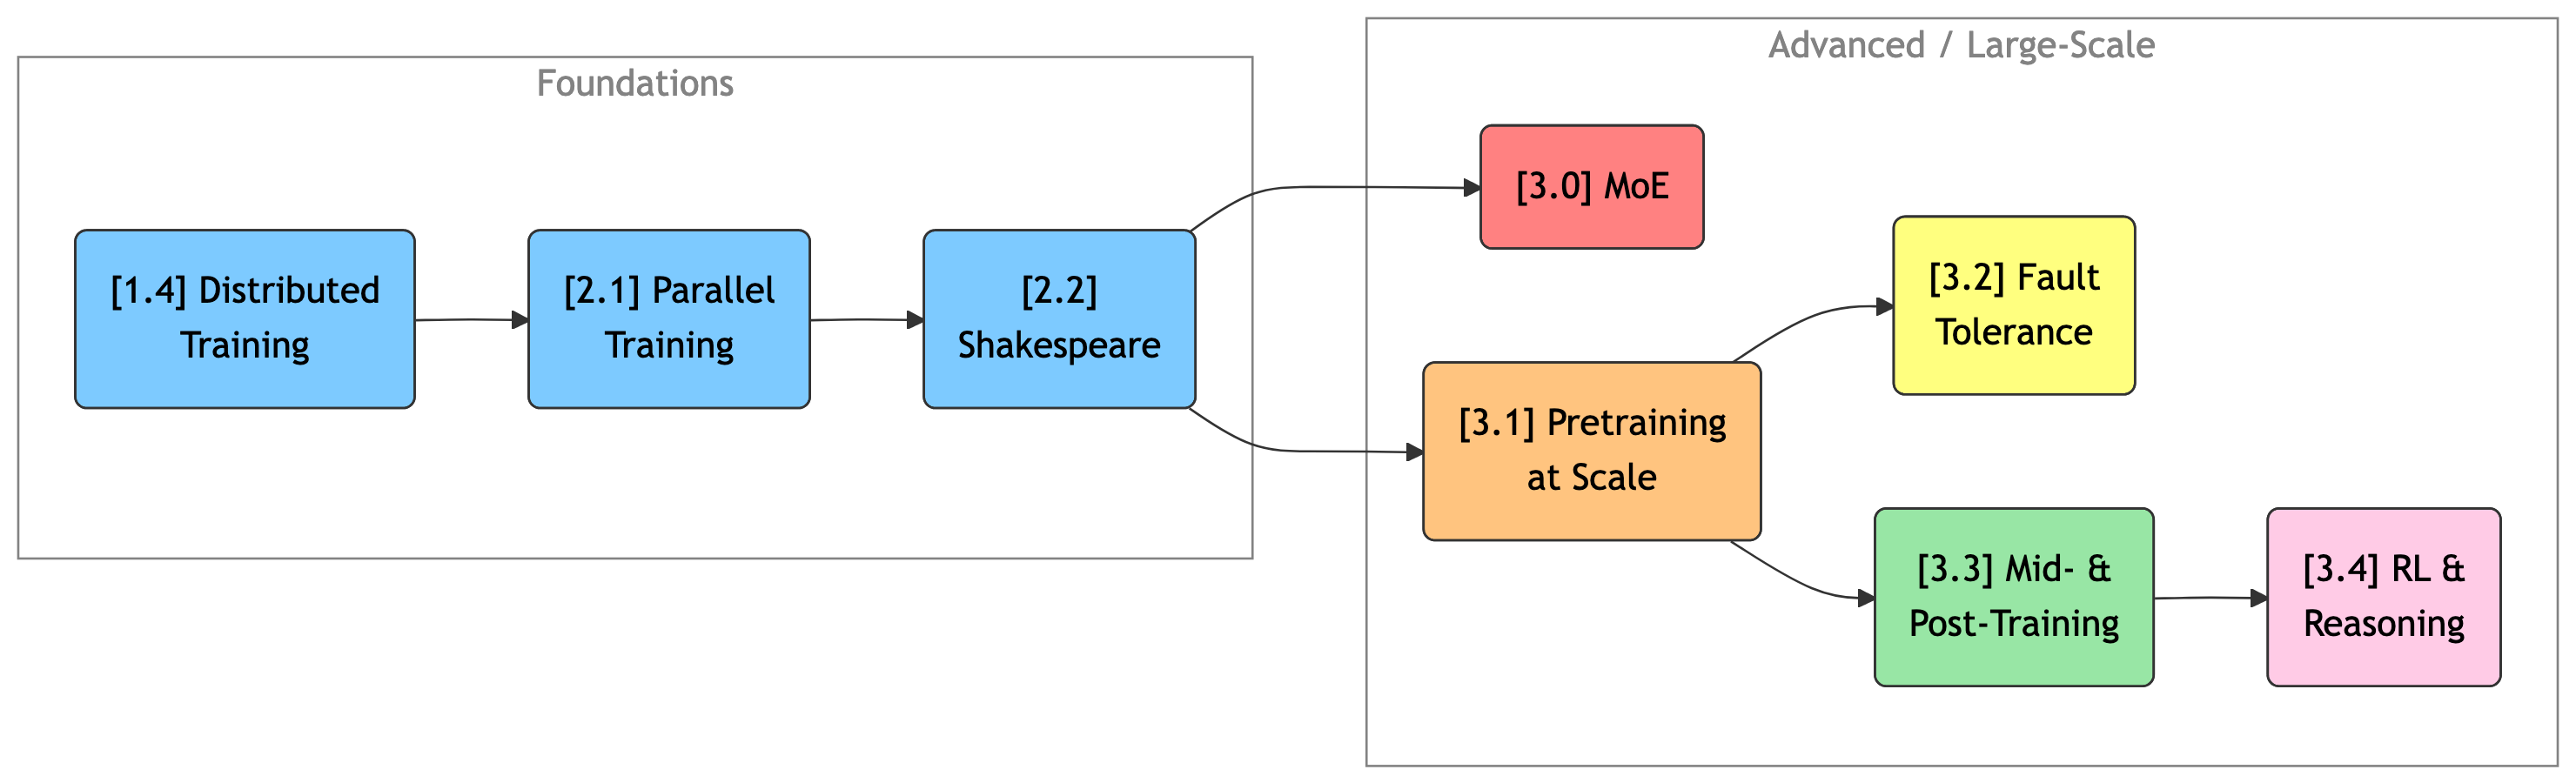

## ⚙️ One-time setup

Every lab in this track uses [`ezpz`](https://github.com/saforem2/ezpz)
to handle the distributed boilerplate. Run this **once** from a fresh
shell to build a virtual environment and install everything:

``` bash
# 1. Build / activate a .venv and load the ezpz shell helpers (system-agnostic)
source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup_env

# 2. Install ezpz into the environment
uv pip install git+https://github.com/saforem2/ezpz

# 3. Smoke-test the distributed setup
ezpz test
```

A healthy `ezpz test` will print your detected device, backend, and
world size, then run a tiny distributed step. That’s your signal the
environment is ready for the labs ahead.

> **Where these run**
>
> The bootcamp labs run on **Jupyter @ [NERSC
> Perlmutter](https://docs.nersc.gov/systems/perlmutter/)** (project
> **`m4388`**, SLURM scheduler, NVIDIA GPUs). But nothing here is
> Perlmutter-specific: `ezpz` auto-detects the scheduler and backend
> (SLURM → `srun`, PBS → `mpiexec`; CUDA / XPU / ROCm / CPU), so the
> exact same commands work unchanged on ALCF, other HPC systems, or a
> single workstation. When a lab shows an allocation flag, it uses a
> placeholder like `-A <project>`; substitute `m4388` on Perlmutter.

> **🧵 Keeping runs alive**
>
> The `ezpz` helpers you install here (`ezpz launch`, `ezpz yeet`,
> `ezpz launch --auto-retry`) are exactly the ones the scaling and
> fault-tolerance labs lean on, so this one setup carries you through
> all five.

Ready? Start with **[\[3.0\] Mixture of Experts & Expert
Parallelism](0-moe/index.qmd)**.